In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf


DATA_PATH = r"C:\Projects\GitHub\Ireland-energy-forecast\data\processed\Final_Model_Solar.csv"
FIG_DIR = r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\figures\EDA_Solar"
os.makedirs(FIG_DIR, exist_ok=True)


df = pd.read_csv(DATA_PATH, parse_dates=["Date"])
df = df.set_index("Date").asfreq("MS")

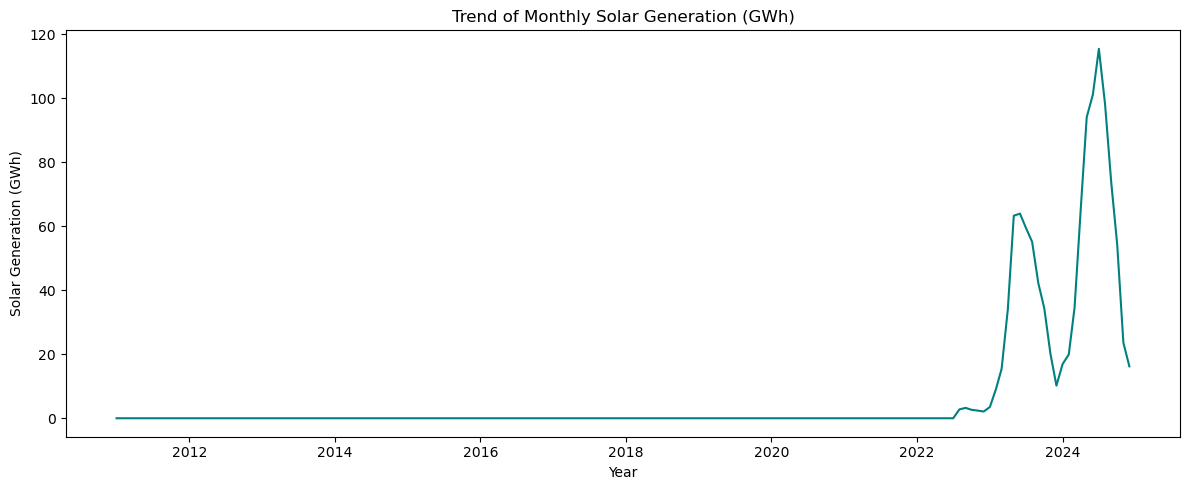

In [ ]:
# Trend of Solar_GWh Over Time 
plt.figure(figsize=(12,5))
plt.plot(df.index, df["Solar_GWh"], color="teal")
plt.title("Trend of Monthly Solar Generation (GWh)")
plt.xlabel("Year")
plt.ylabel("Solar Generation (GWh)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "solar_trend.png"), dpi=300)
plt.show()
plt.close()

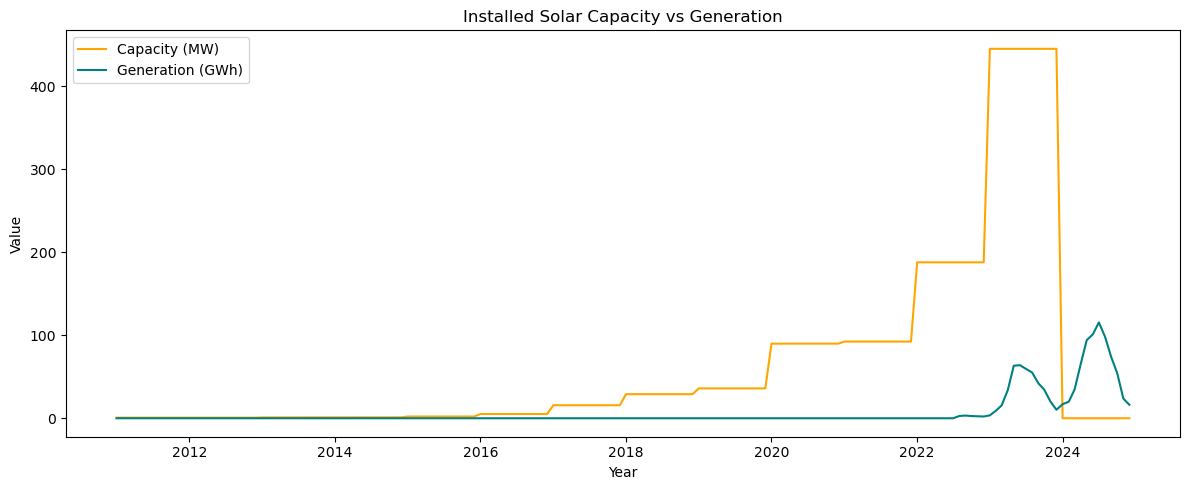

In [ ]:
# Installed Solar Capacity Over Time 
plt.figure(figsize=(12,5))
plt.plot(df.index, df["Solar_Capacity_MW"], color="orange", label="Capacity (MW)")
plt.plot(df.index, df["Solar_GWh"], color="teal", label="Generation (GWh)")
plt.legend()
plt.title("Installed Solar Capacity vs Generation")
plt.xlabel("Year")
plt.ylabel("Value")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "solar_capacity_vs_generation.png"), dpi=300)
plt.show()
plt.close()

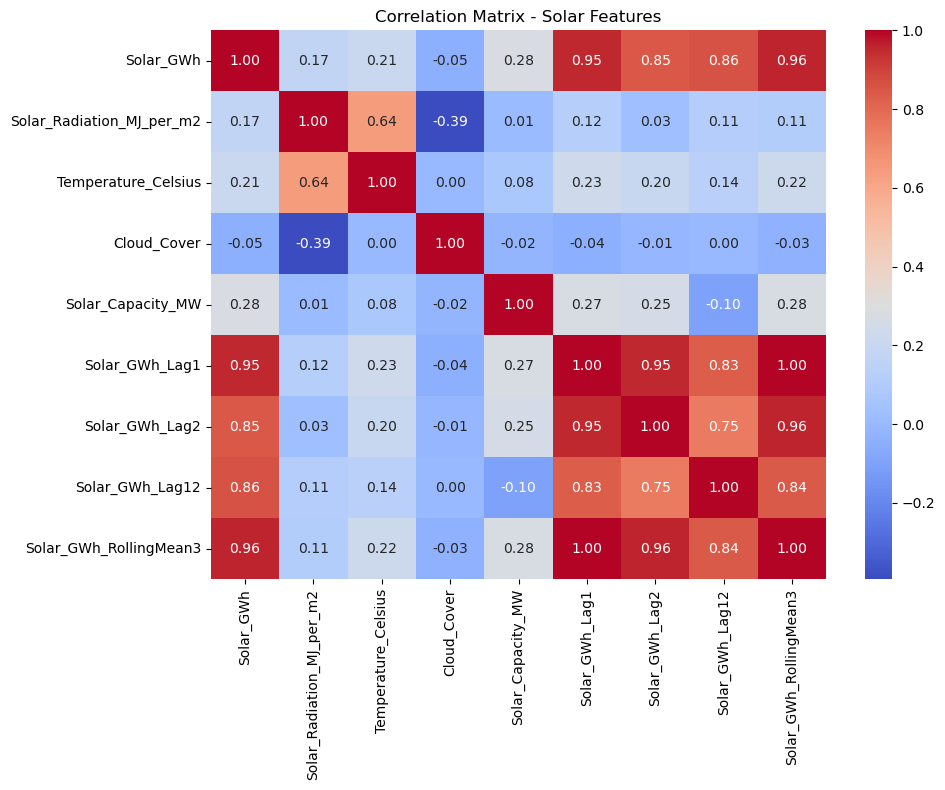

In [ ]:
 # Correlation Matrix 
corr_cols = ["Solar_GWh", "Solar_Radiation_MJ_per_m2", "Temperature_Celsius", 
             "Cloud_Cover", "Solar_Capacity_MW", 
             "Solar_GWh_Lag1", "Solar_GWh_Lag2", "Solar_GWh_Lag12", "Solar_GWh_RollingMean3"]
plt.figure(figsize=(10,8))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix - Solar Features")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "solar_corr_matrix.png"), dpi=300)
plt.show()
plt.close()

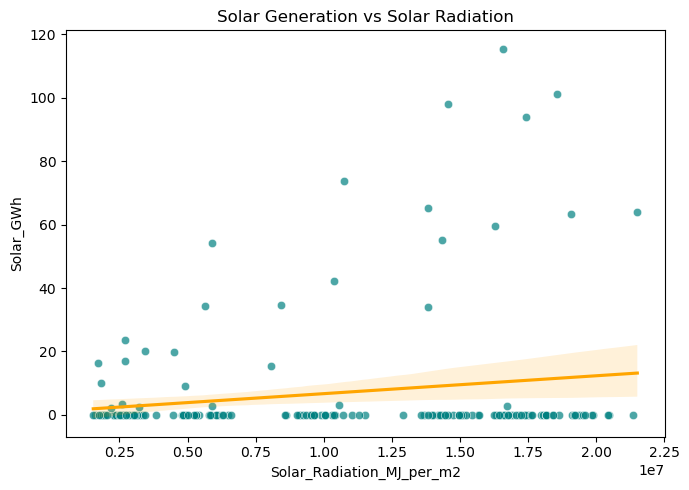

In [ ]:
# Scatter: Solar_GWh vs Solar_Radiation
plt.figure(figsize=(7,5))
sns.scatterplot(x="Solar_Radiation_MJ_per_m2", y="Solar_GWh", data=df, color="teal", alpha=0.7)
sns.regplot(x="Solar_Radiation_MJ_per_m2", y="Solar_GWh", data=df, scatter=False, color="orange")
plt.title("Solar Generation vs Solar Radiation")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "solar_vs_radiation.png"), dpi=300)
plt.show()
plt.close()

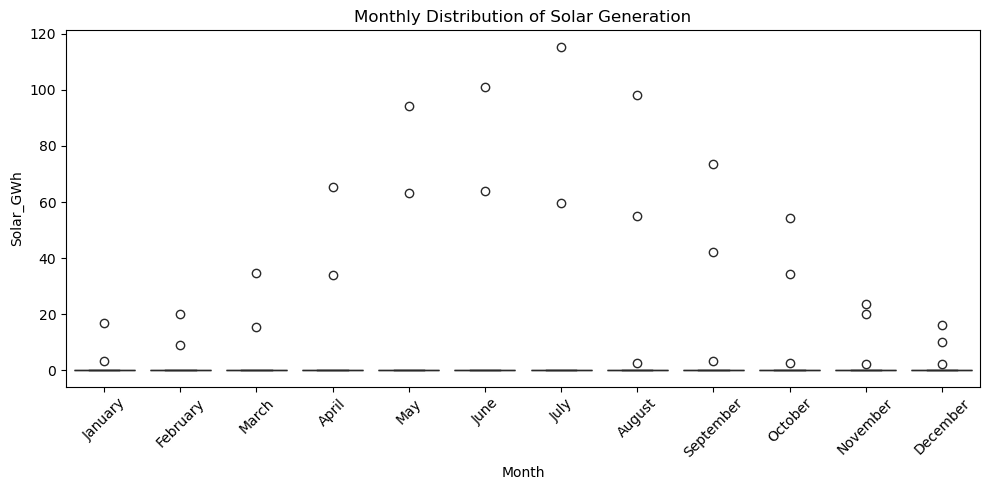

In [ ]:
# Boxplot by Month 
df["Month"] = df.index.month_name()

plt.figure(figsize=(10,5))
sns.boxplot(x="Month", y="Solar_GWh", data=df, hue="Month", palette="viridis", legend=False)
plt.xticks(rotation=45)
plt.title("Monthly Distribution of Solar Generation")
plt.tight_layout()

# Show and save
plt.savefig(os.path.join(FIG_DIR, "solar_boxplot_by_month.png"), dpi=300)
plt.show()


<Figure size 1000x500 with 0 Axes>

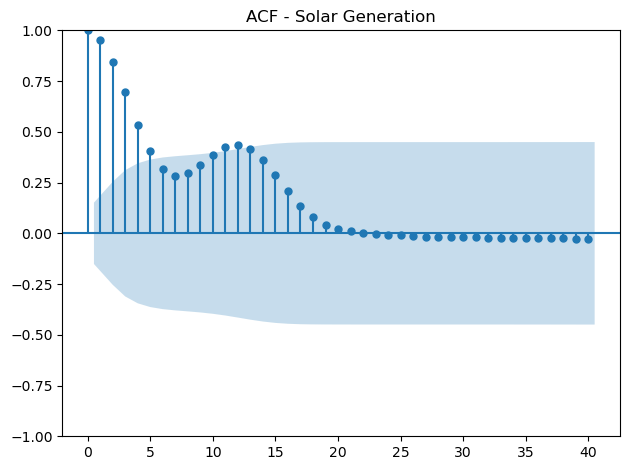

In [ ]:
#  Lag Effects - ACF 
plt.figure(figsize=(10,5))
plot_acf(df["Solar_GWh"].dropna(), lags=40)
plt.title("ACF - Solar Generation")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "solar_acf.png"), dpi=300)
plt.show()
plt.close()

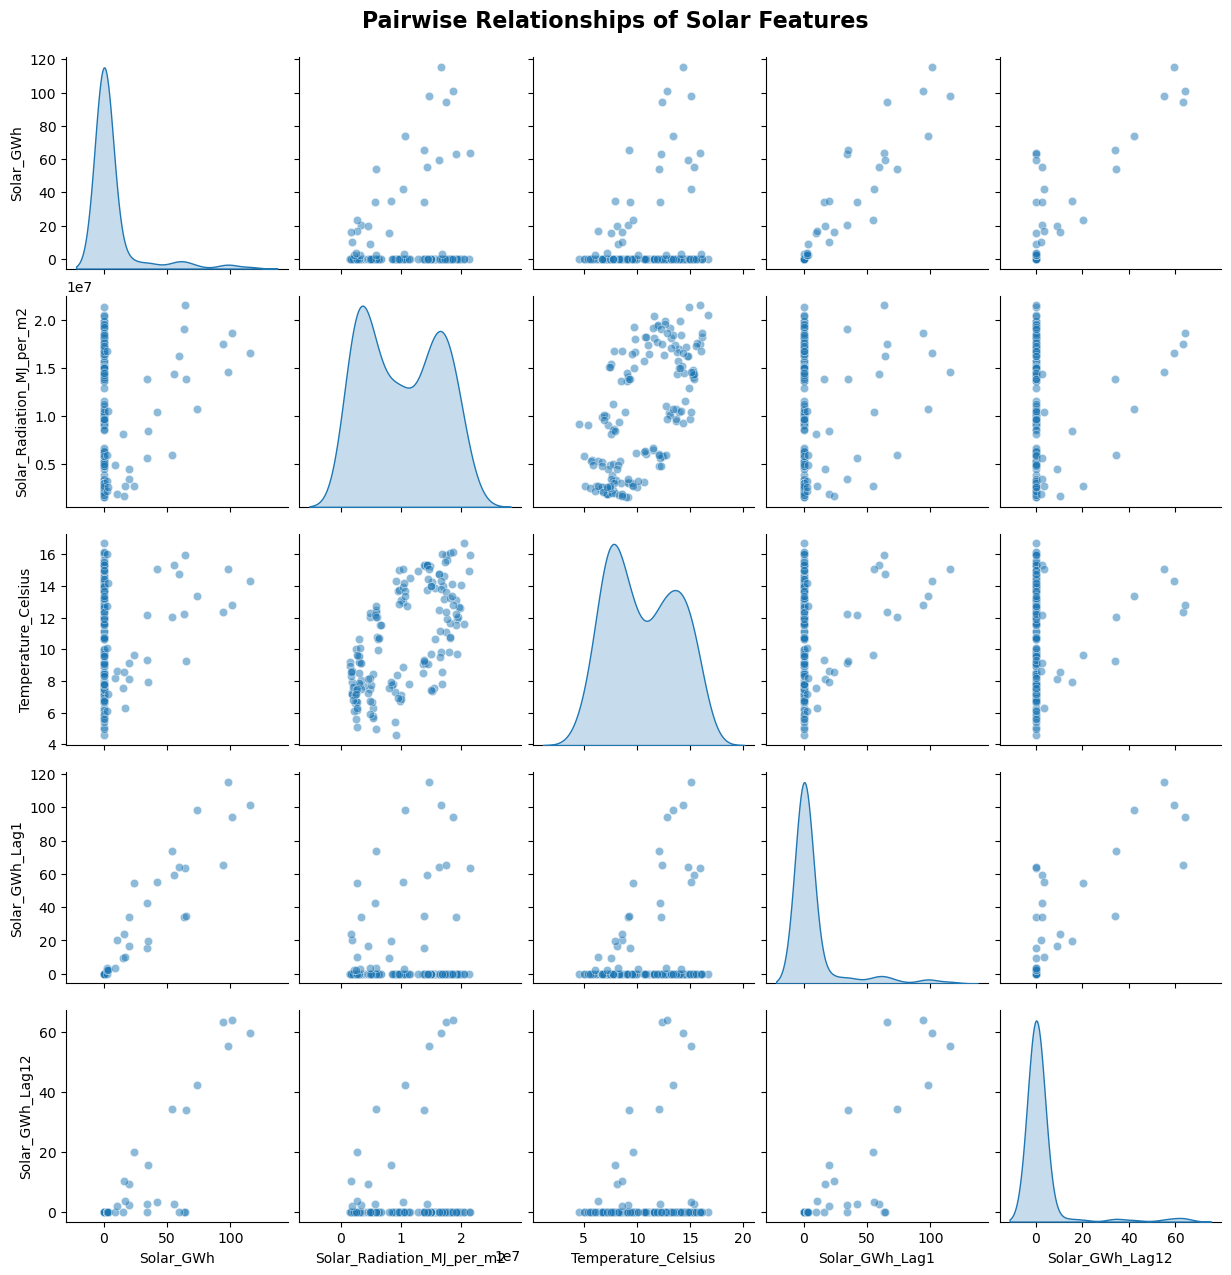

In [ ]:
# Pairplot with Title
import seaborn as sns
import matplotlib.pyplot as plt
import os

pair_cols = ["Solar_GWh", "Solar_Radiation_MJ_per_m2", "Temperature_Celsius", 
             "Solar_GWh_Lag1", "Solar_GWh_Lag12"]

pairplot = sns.pairplot(df[pair_cols], diag_kind="kde", plot_kws={"alpha": 0.5})


pairplot.fig.suptitle("Pairwise Relationships of Solar Features", 
                      fontsize=16, fontweight="bold", y=1.02)


plt.savefig(os.path.join(FIG_DIR, "Pairwise Relationships of Solar Features.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("../../data/processed/Final_Model_Solar.csv", parse_dates=["Date"])
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year

# Find earliest year with >= 10 non-zero months
min_year = (
    df.groupby("Year")["Solar_GWh"]
    .apply(lambda x: (x > 0).sum() >= 10)
    .idxmax()
)

print(f" First stable year: {min_year}")

# Slice data 
df_stable = df[df["Year"] >= min_year]

# Month name order 
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
df_stable["MonthName"] = df_stable["Month"].apply(lambda m: month_order[m-1])


plt.figure(figsize=(10, 6))
sns.boxplot(data=df_stable, x="MonthName", y="Solar_GWh",
            order=month_order, palette="YlOrBr")

plt.title(f"Monthly Solar Generation (GWh) — Data from {min_year} Onwards")
plt.xlabel("Month")
plt.ylabel("Solar Generation (GWh)")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()



In [ ]:
# Solar Capacity — Milestone Annotations
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = df.copy()  # keep original safe
cap = df["Solar_Capacity_MW"].astype(float)


FIG_DIR = r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\figures\EDA_Solar"
os.makedirs(FIG_DIR, exist_ok=True)

# Colors
TEAL = "#138D75"
MUTED = "#7F8C8D"

# first date capacity crosses each threshold
thresholds = [1, 10, 50, 100, 200, 300, 400]
milestones = []
for th in thresholds:
    hit = cap[cap >= th]
    if not hit.empty:
        milestones.append((th, hit.index[0], float(hit.iloc[0])))

#  top 3 month-over-month capacity jumps
deltas = cap.diff()
jumps = deltas.sort_values(ascending=False).head(6)  # taking a few extra then de-dupe by year
# keeping distinct years optional, so labels don't stack on one date range
picked = []
years_used = set()
for idx, val in jumps.items():
    if pd.isna(val) or val <= 0: 
        continue
    if idx.year in years_used:
        continue
    picked.append((idx, float(val), float(cap.loc[idx])))
    years_used.add(idx.year)
    if len(picked) == 3:
        break

# Plot
plt.rcParams["axes.grid"] = False
plt.rcParams["figure.facecolor"] = "white"

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cap.index, cap.values, color=TEAL, linewidth=2.5, label="Installed Solar Capacity (MW)")


if "Solar_GWh" in df.columns:
    ax2 = ax.twinx()
    ax2.plot(df.index, df["Solar_GWh"].values, color=MUTED, alpha=0.35, linewidth=1.5, label="Solar Generation (GWh)")
    ax2.set_ylabel("Solar Generation (GWh)", color=MUTED)
    ax2.tick_params(axis='y', colors=MUTED)

# Axis labels and title
ax.set_title("Solar Capacity Over Time — Milestones & Big Jumps", fontsize=13, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Installed Capacity (MW)")

# Annotate capacity milestones, first time crossing thresholds
for th, when, val in milestones:
    ax.scatter(when, val, s=45, color=TEAL, edgecolor="white", linewidth=0.8, zorder=3)
    ax.annotate(f"{th} MW",
                xy=(when, val),
                xytext=(10, 12), textcoords="offset points",
                fontsize=9, fontweight="bold", color=TEAL,
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec=TEAL, lw=0.8, alpha=0.9),
                arrowprops=dict(arrowstyle="->", color=TEAL, lw=1))

# Annotate top 3 MoM jumps, largest capacity additions
for when, delta, val in picked:
    ax.scatter(when, val, s=55, color=TEAL, edgecolor="white", linewidth=1.0, zorder=4)
    ax.annotate(f"↑ +{delta:.1f} MW",
                xy=(when, val),
                xytext=(-10, -28), textcoords="offset points",
                fontsize=9, color="black",
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#333", lw=0.6, alpha=0.95),
                arrowprops=dict(arrowstyle="->", color="#333", lw=1))

# Cleaning spines & legend
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
handles, labels = ax.get_legend_handles_labels()
if "Solar_GWh" in df.columns:
    h2, l2 = ax2.get_legend_handles_labels()
    handles += h2; labels += l2
ax.legend(handles, labels, frameon=False, loc="upper left")

plt.tight_layout()
out = os.path.join(FIG_DIR, "solar_capacity_milestones.png")
plt.savefig(out, dpi=300)
plt.close()
print(" Saved:", out)
